# Myanmar Handwriting Recognition ML Model - 1

## Model 1 – Syllable Prototype + Unit Prototype Segmental HMM (Hybrid Scoring)

Model‑1 is the first recognition model in this project and uses a **hybrid classical approach** for Myanmar handwriting recognition.

This model combines two complementary components:

1. **Syllable Prototype Scoring**  
   A handwriting sample is compared against learned syllable-level prototype embeddings to obtain a global similarity score.

2. **Unit Prototype + Segmental HMM Scoring**  
   The handwriting sample is also analyzed at the unit level. A segmental HMM is used to segment the stroke sequence into unit-level segments, and each segment is scored using learned unit prototypes.

The final recognition result is obtained by combining:
- a **global syllable prototype score**
- a **structured unit-sequence score from the segmental HMM**

This allows the model to use both:
- **global syllable similarity**
- **local structured unit matching**

As a result, Model‑1 provides an interpretable and low-cost baseline for Myanmar handwriting recognition.



```mermaid

flowchart TD
    A[Handwriting strokes / embeddings] --> B[Syllable Prototype Scoring]
    B --> C[Global syllable score]

    A --> D[Segmental HMM over unit sequence]
    D --> E[Stroke-to-unit segmentation]
    E --> F[Unit Prototype Scoring]
    F --> G[Unit-sequence score]

    C --> H[Hybrid score combination]
    G --> H

    H --> I[Final predicted syllable]

```

### DataSet Loading
Strokes ( series of x, y, timestamp ) infromation are load to Pandas Dataframe.

In [65]:
# @title Load Dataset
from load_dataset import get_syllable_df, load_all_strokes, build_train_df

syl_path = '../syl.txt'
hw_path = '../dataset/Aung_Hein/'

processed_df, syllable_df, stroke_df, char2idx, idx2char = build_train_df(syl_path, hw_path)
processed_df['sample_index'] = processed_df.index

In [2]:
#Font for matplot

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/mm/Pyidaungsu-2.3_Regular.ttf"

fm.fontManager.addfont(font_path)

prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()

In [3]:
from writing_units import (
    WritingUnitConfig,
    add_unit_array_columns,
    summarize_unit_conversion,
    add_align_array_columns
)

unit_cfg = WritingUnitConfig(
    merge_base_asat=True,
    merge_virama_next_base=True,
    keep_unit_meta=True,
    annotate_role_in_unit_string=False,
)

processed_units_df = add_unit_array_columns(
    processed_df,
    char_array_col="char_array",
    syllable_col="syllable",
    config=unit_cfg,
)

processed_units_df = add_align_array_columns(processed_units_df)

processed_units_df['sample_index'] = processed_units_df.index

In [4]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    processed_units_df,
    test_size=0.20,
    random_state=42,
    shuffle=True,
)

print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

Train rows: 10570
Test rows : 2643


In [5]:
syllable_df = (
    processed_units_df[["syllable", "char_array"]]
    .drop_duplicates("syllable")
    .reset_index(drop=True)
)

print("Num unique syllables:", len(syllable_df))

Num unique syllables: 4377


### Embedding

In [6]:
from embedding import embed_stroke_dataframe, stack_embeddings

train_emb_df = embed_stroke_dataframe(train_df)
test_emb_df  = embed_stroke_dataframe(test_df)
full_emb_df  = embed_stroke_dataframe(processed_units_df)

### Helpers

In [7]:
from writing_units import infer_unicode_myanmar_role

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

from prototype import score_query_against_all_syllables


def top1_confusion_matrix(pred_df: pd.DataFrame):
    cm = pd.crosstab(
        pred_df["true_syllable"].astype(str),
        pred_df["pred_top1"].astype(str),
        rownames=["true"],
        colnames=["pred"],
        dropna=False,
    )
    return cm

def top1_confusion_matrix_normalized(pred_df: pd.DataFrame):
    cm = top1_confusion_matrix(pred_df)
    cm_norm = cm.div(cm.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    return cm_norm

def top_confusion_pairs(pred_df: pd.DataFrame, top_n: int = 30):
    err_df = pred_df[
        pred_df["true_syllable"].astype(str) != pred_df["pred_top1"].astype(str)
    ].copy()

    out = (
        err_df.groupby(["true_syllable", "pred_top1"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    return out.head(top_n)


def per_syllable_top1_recall(pred_df: pd.DataFrame):
    tmp = pred_df.copy()
    tmp["correct_top1"] = (
        tmp["true_syllable"].astype(str) == tmp["pred_top1"].astype(str)
    )

    out = (
        tmp.groupby("true_syllable")
        .agg(
            n=("sample_index", "count"),
            top1_recall=("correct_top1", "mean"),
        )
        .reset_index()
        .sort_values(["top1_recall", "n"], ascending=[True, False])
        .reset_index(drop=True)
    )
    return out

def build_syllable_to_first_base(syllable_df):
    out = {}
    for _, row in syllable_df.iterrows():
        chars = list(row["char_array"])
        bases = [c for c in chars if infer_unicode_myanmar_role(c) == "BASE"]
        out[row["syllable"]] = bases[0] if bases else None
    return out


def add_first_base_columns(pred_df: pd.DataFrame, syllable_to_first_base: dict):
    out = pred_df.copy()
    out["true_base"] = out["true_syllable"].astype(str).map(syllable_to_first_base)
    out["pred_base"] = out["pred_top1"].astype(str).map(syllable_to_first_base)
    return out



def topk_accuracy_from_pred_df(pred_df: pd.DataFrame, k: int):
    """
    pred_df must contain:
      - true_syllable
      - pred_topk  (list of predictions)
    """
    hits = []
    for _, row in pred_df.iterrows():
        true = str(row["true_syllable"])
        preds = [str(x) for x in row["pred_topk"][:k]]
        hits.append(true in preds)
    return float(np.mean(hits)) if len(hits) > 0 else np.nan
    

def evaluate_syllable_prototype_only(
    emb_df: pd.DataFrame,
    *,
    prototype_bank,
    sample_index_col: str = "sample_index",
    syllable_col: str = "syllable",
    final_top_k: int = 10,
):
    """
    Evaluate pure syllable-prototype ranking.

    For each sample:
      - score against all syllable prototypes
      - take top-K directly

    Returns:
      pred_df
    """
    rows = []

    sample_ids = (
        emb_df[sample_index_col]
        .drop_duplicates()
        .astype(int)
        .tolist()
    )

    for sid in sample_ids:
        qdf = emb_df[emb_df[sample_index_col] == sid].copy()

        true_syllable = str(qdf[syllable_col].iloc[0])

        score_df = score_query_against_all_syllables(
            qdf,
            prototype_bank,
            return_details=False,
        )

        score_df = score_df.sort_values("score", ascending=False).reset_index(drop=True)
        topk = score_df["syllable_label"].astype(str).tolist()[:final_top_k]

        rows.append({
            "sample_index": sid,
            "true_syllable": true_syllable,
            "pred_top1": topk[0] if len(topk) > 0 else None,
            "pred_topk": topk,
        })

    pred_df = pd.DataFrame(rows)
    return pred_df

def base_confusion_matrix(pred_df: pd.DataFrame, syllable_to_first_base: dict):
    tmp = add_first_base_columns(pred_df, syllable_to_first_base)
    cm = pd.crosstab(
        tmp["true_base"].astype(str),
        tmp["pred_base"].astype(str),
        rownames=["true_base"],
        colnames=["pred_base"],
        dropna=False,
    )
    return cm

def base_confusion_matrix_normalized(pred_df: pd.DataFrame, syllable_to_first_base: dict):
    cm = base_confusion_matrix(pred_df, syllable_to_first_base)
    cm_norm = cm.div(cm.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    return cm_norm

def _to_xy(stroke):
    arr = np.asarray(stroke, dtype=np.float32)
    return arr[:, :2]

def get_sample_strokes(
    source_df: pd.DataFrame,
    sample_index,
    *,
    sample_index_col: str = "sample_index",
    cleaned_col: str = "cleaned_strokes",
    fallback_col: str = "strokes",
):
    rows = source_df[source_df[sample_index_col] == sample_index]
    if len(rows) == 0:
        raise KeyError(f"sample_index={sample_index} not found")

    row0 = rows.iloc[0]
    if cleaned_col in row0.index and isinstance(row0.get(cleaned_col, None), (list, tuple)):
        return row0[cleaned_col]
    if fallback_col in row0.index and isinstance(row0.get(fallback_col, None), (list, tuple)):
        return row0[fallback_col]

    raise KeyError(f"Neither '{cleaned_col}' nor '{fallback_col}' found for sample {sample_index}")

import numpy as np
import pandas as pd

from prototype import score_query_against_all_syllables
from segmental_hmm import decode_one_sample_segmental_hmm
from unit_prototype import (
    score_unit_sequence_with_grammar,
    UnitGrammarConfig,
    UnitPrototypeConfig,
)
from writing_units import infer_unicode_myanmar_role

NEG_FLOOR = -1e6


# ============================================================
# Helpers
# ============================================================

def safe_zscore(values):
    x = np.asarray(values, dtype=np.float64)
    x[~np.isfinite(x)] = np.nan
    if np.all(np.isnan(x)):
        return np.zeros_like(x)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if sd < 1e-8:
        return np.zeros_like(x)
    return np.nan_to_num((x - mu) / sd)


def extract_segment_embeddings_keep_zeros(sample_df, segments, emb_col="embedding"):
    emb_dim = len(sample_df.iloc[0][emb_col])
    seg_embs = []
    for s, e in segments:
        if e <= s:
            seg_embs.append(np.zeros((emb_dim,), dtype=np.float32))
        else:
            X = np.vstack(sample_df.iloc[s:e][emb_col].values)
            seg_embs.append(X.mean(axis=0))
    return seg_embs


def build_syllable_to_first_base(syllable_df):
    out = {}
    for _, row in syllable_df.iterrows():
        chars = list(row["char_array"])
        bases = [c for c in chars if infer_unicode_myanmar_role(c) == "BASE"]
        out[row["syllable"]] = bases[0] if bases else None
    return out


def same_first_base(a, b, base_map):
    return base_map.get(a) is not None and base_map.get(a) == base_map.get(b)


def trust_to_unit_support(unit_trust: float) -> float:
    """
    Convert unit_trust into extra unit weight used ONLY for same-base reranking.

    New stronger curve:
      < 0.15  -> no extra support
      0.15-0.35 -> moderate support up to 0.18
      0.35-0.60 -> stronger support up to 0.28
      > 0.60 -> cap at 0.30

    Output range: [0.0, 0.30]
    """
    t = float(unit_trust)

    if t < 0.15:
        return 0.0

    elif t < 0.35:
        # 0.00 -> 0.18
        return 0.18 * (t - 0.15) / 0.20

    elif t < 0.60:
        # 0.18 -> 0.28
        return 0.18 + 0.10 * (t - 0.35) / 0.25

    else:
        return 0.30

def softmax_scores(values, temperature=0.50):
    """
    Temperature-scaled softmax.
    Smaller temperature -> sharper probabilities.
    """
    x = np.asarray(values, dtype=np.float64) / max(temperature, 1e-8)
    x = x - np.max(x)
    ex = np.exp(x)
    return ex / (np.sum(ex) + 1e-12)


def confidence_from_scores(values, temperature=0.50):
    """
    Confidence from one branch's candidate scores.

    Returns:
      conf, top1_prob, top2_prob
    where
      conf = top1_prob - top2_prob
    """
    probs = softmax_scores(values, temperature=temperature)
    probs_sorted = np.sort(probs)[::-1]

    top1 = float(probs_sorted[0]) if len(probs_sorted) > 0 else 0.0
    top2 = float(probs_sorted[1]) if len(probs_sorted) > 1 else 0.0
    conf = top1 - top2
    return conf, top1, top2

def confidence_from_unit_branch(
    unit_hmm_scores,
    unit_proto_scores,
    *,
    temp_hmm: float = 0.50,
    temp_proto: float = 0.50,
    hmm_conf_weight: float = 0.70,
    proto_conf_weight: float = 0.30,
    agreement_bonus: float = 0.05,
):
    """
    Compute a stronger unit confidence using:
      - HMM confidence
      - proto confidence
      - agreement bonus when both top-1 candidates match

    Returns:
      conf_unit,
      unit_conf_info (dict)
    """
    # confidence from HMM branch alone
    conf_hmm, top1_hmm_prob, top2_hmm_prob = confidence_from_scores(
        unit_hmm_scores,
        temperature=temp_hmm,
    )

    # confidence from proto branch alone
    conf_proto, top1_proto_prob, top2_proto_prob = confidence_from_scores(
        unit_proto_scores,
        temperature=temp_proto,
    )

    # branch top-1 labels are determined by argmax position
    top1_hmm_idx = int(np.argmax(unit_hmm_scores))
    top1_proto_idx = int(np.argmax(unit_proto_scores))

    agree = (top1_hmm_idx == top1_proto_idx)
    bonus = agreement_bonus if agree else 0.0

    conf_unit = (
        hmm_conf_weight * conf_hmm +
        proto_conf_weight * conf_proto +
        bonus
    )

    info = {
        "conf_hmm": conf_hmm,
        "conf_proto": conf_proto,
        "top1_hmm_prob": top1_hmm_prob,
        "top2_hmm_prob": top2_hmm_prob,
        "top1_proto_prob": top1_proto_prob,
        "top2_proto_prob": top2_proto_prob,
        "top1_hmm_idx": top1_hmm_idx,
        "top1_proto_idx": top1_proto_idx,
        "unit_agree": agree,
        "unit_agreement_bonus": bonus,
    }

    return conf_unit, info



# ============================================================
# Unit scoring with diagnostics
# ============================================================

def score_candidate_unit(
    sample_index,
    syllable,
    emb_df,
    item_units,
    seg_model_units,
    unit_proto_bank,
    syllable_to_units,
    unit_to_role,
    role_bigram_logprob,
    grammar_cfg,
    unit_proto_cfg,
):
    hmm_df = decode_one_sample_segmental_hmm(
        item_units,
        seg_model_units,
        candidate_syllables=[syllable],
        top_k=1,
    )

    if len(hmm_df) == 0:
        return {
            "unit_hmm_score": NEG_FLOOR,
            "unit_proto_score": NEG_FLOOR,
            "first_base": None,
            "zero_rate": 1.0,
            "bad_zero_role_count": 1,
        }

    unit_hmm_score = float(hmm_df.iloc[0]["score"])
    segments = hmm_df.iloc[0]["segments"]

    sample_df = (
        emb_df[emb_df["sample_index"] == sample_index]
        .sort_values("stroke_index")
        .reset_index(drop=True)
    )

    seg_embs = extract_segment_embeddings_keep_zeros(sample_df, segments)
    unit_seq = syllable_to_units.get(syllable, ())

    unit_proto_score = score_unit_sequence_with_grammar(
        unit_embeddings=seg_embs,
        unit_labels=list(unit_seq),
        unit_bank=unit_proto_bank,
        proto_config=unit_proto_cfg,
        grammar_cfg=grammar_cfg,
        unit_to_role=unit_to_role,
        role_bigram_logprob=role_bigram_logprob,
    )

    seg_lens = [max(0, e - s) for s, e in segments]
    zero_rate = sum(l == 0 for l in seg_lens) / max(len(seg_lens), 1)

    roles = [unit_to_role.get(u, "OTHER") for u in unit_seq]
    CRIT = {"BASE", "E_BASE", "STACKED_BASE", "FINAL_ASAT", "TONE"}
    bad_zero = sum((l == 0 and r in CRIT) for l, r in zip(seg_lens, roles))

    first_base = None
    for u, r in zip(unit_seq, roles):
        if r in {"BASE", "E_BASE", "STACKED_BASE"}:
            first_base = u
            break

    return {
        "unit_hmm_score": unit_hmm_score,
        "unit_proto_score": unit_proto_score,
        "first_base": first_base,
        "zero_rate": zero_rate,
        "bad_zero_role_count": bad_zero,
    }


# ============================================================
# Candidate-level unit trust
# ============================================================

def compute_unit_trust(cand_df):
    unit_rank = cand_df.sort_values("unit_model_score", ascending=False).reset_index(drop=True)
    hmm_rank = cand_df.sort_values("unit_hmm_norm", ascending=False).reset_index(drop=True)
    proto_rank = cand_df.sort_values("unit_proto_norm", ascending=False).reset_index(drop=True)

    top = unit_rank.iloc[0]

    hmm_gap = hmm_rank.iloc[0]["unit_hmm_norm"] - hmm_rank.iloc[1]["unit_hmm_norm"]
    proto_gap = proto_rank.iloc[0]["unit_proto_norm"] - proto_rank.iloc[1]["unit_proto_norm"]

    same_base = unit_rank[
        (unit_rank["first_base"] == top["first_base"]) &
        (unit_rank["syllable"] != top["syllable"])
    ]

    same_base_gap = (
        top["unit_model_score"] - same_base["unit_model_score"].max()
        if len(same_base) > 0 else 0.0
    )

    unit_agree = (
        hmm_rank.iloc[0]["syllable"] ==
        proto_rank.iloc[0]["syllable"]
    )

    seg_penalty = min(1.0, 0.5 * top["zero_rate"] + 0.5 * (top["bad_zero_role_count"] > 0))

    def squash(x, s): return np.clip(x / s, 0.0, 1.0)

    trust = (
        0.40 * squash(hmm_gap, 0.4) +
        0.20 * squash(proto_gap, 0.25) +
        0.20 * squash(same_base_gap, 0.30) +
        0.10 * (1.0 if unit_agree else -0.5) -
        0.10 * seg_penalty
    )

    return float(np.clip(trust, 0.0, 1.0)), {
        "unit_trust": trust,
        "hmm_gap": hmm_gap,
        "proto_gap": proto_gap,
        "same_base_gap": same_base_gap,
        "unit_agree": unit_agree,
        "zero_rate": top["zero_rate"],
        "bad_zero_role_count": top["bad_zero_role_count"],
    }



# ============================================================
# FINAL DECODER
# ============================================================
def hybrid_decode_sample_dynamic(
    sample_index,
    emb_df,
    test_items_units,
    seg_model_units,
    prototype_bank,
    unit_proto_bank,
    syllable_to_units,
    shortlist_by_sample,
    unit_to_role,
    role_bigram_logprob,
    grammar_cfg,
    unit_proto_cfg,
    syllable_to_first_base,
    *,
    shape_shortlist_k=25,
    final_top_k=10,
):
    qdf = emb_df[emb_df["sample_index"] == sample_index]
    item_units = test_items_units[sample_index]

    proto_df = score_query_against_all_syllables(qdf, prototype_bank, return_details=False)
    proto_map = dict(zip(proto_df["syllable_label"], proto_df["score"]))

    rows = []
    for syll in shortlist_by_sample[sample_index][:shape_shortlist_k]:
        uinfo = score_candidate_unit(
            sample_index, syll, emb_df, item_units, seg_model_units,
            unit_proto_bank, syllable_to_units,
            unit_to_role, role_bigram_logprob,
            grammar_cfg, unit_proto_cfg,
        )
        rows.append({
            "syllable": syll,
            "syll_score": proto_map.get(syll, NEG_FLOOR),
            **uinfo,
        })

    cand_df = pd.DataFrame(rows)

    cand_df["syll_norm"] = safe_zscore(cand_df["syll_score"])
    cand_df["unit_hmm_norm"] = safe_zscore(cand_df["unit_hmm_score"])
    cand_df["unit_proto_norm"] = safe_zscore(cand_df["unit_proto_score"])

    cand_df["unit_model_score"] = (
        0.80 * cand_df["unit_hmm_norm"] +
        0.20 * cand_df["unit_proto_norm"]
    )

    # syll confidence
    conf_syll, top1_syll_prob, top2_syll_prob = confidence_from_scores(
        cand_df["syll_norm"].values,
        temperature=0.50,
    )

    # unit trust
    trust, trust_info = compute_unit_trust(cand_df)

    # fixed blend
    cand_df["final_score"] = (
        0.60 * cand_df["syll_norm"] +
        0.40 * cand_df["unit_model_score"]
    )

    syll_top = cand_df.sort_values("syll_norm", ascending=False).iloc[0]["syllable"]
    unit_top = cand_df.sort_values("unit_model_score", ascending=False).iloc[0]["syllable"]

    same_base_ok = same_first_base(syll_top, unit_top, syllable_to_first_base)
    unit_support = trust_to_unit_support(trust)

    if same_base_ok and unit_support > 0:
        base = syllable_to_first_base[syll_top]
        mask = cand_df["syllable"].map(syllable_to_first_base) == base
        cand_df.loc[mask, "final_score"] = (
            (1 - unit_support) * cand_df.loc[mask, "syll_norm"] +
            unit_support * cand_df.loc[mask, "unit_model_score"]
        )

    cand_df = cand_df.sort_values("final_score", ascending=False).reset_index(drop=True)

    final_top1 = str(cand_df.iloc[0]["syllable"])
    topk = [final_top1] + [str(s) for s in cand_df["syllable"] if str(s) != final_top1]
    topk = topk[:final_top_k]

    branch_info = {
        "conf_syll": conf_syll,
        "conf_unit": trust,   # new trust score
        "top1_syll_prob": top1_syll_prob,
        "top2_syll_prob": top2_syll_prob,
        "w_syll": 0.60,
        "w_unit": 0.40,
        "same_base_ok": same_base_ok,
        "unit_support": unit_support,
        "top1_source": (
            "unit_same_base_support"
            if (same_base_ok and unit_support > 0)
            else "blend"
        ),
        "top1_syll_label": str(syll_top),
        "top1_unit_label": str(unit_top),
        **trust_info,
    }

    return topk, cand_df, branch_info


from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Iterable
from collections import defaultdict
import numpy as np
import pandas as pd
import unicodedata as ud

# ============================================================
# Constants / small helpers
# ============================================================

@dataclass
class BaselineUnitSeqConfig:
    """
    Deterministic baseline-unit conversion from canonical char_array.
    This should match the same logic as your baseline unitization rules.
    """
    merge_e_aa: bool = True         # ေ + ာ -> ော
    merge_e_tall_aa: bool = True    # ေ + ါ -> ေါ
    merge_i_u: bool = False         # optional later

    merge_base_asat: bool = True    # BASE + ် -> merged final
    merge_tall_aa_asat: bool = True # ာ + ်
    merge_nga_asat: bool = True     # င + ်
    merge_virama_next_base: bool = True

    merge_medial_ya_ha: bool = True
    merge_medial_pairs: bool = True
    merge_medial_triplets: bool = False


MY_ASAT = "်"
MY_VIRAMA = "္"
MY_E = "ေ"
MY_AA = "ာ"
MY_TALL_AA = "ါ"

MY_MEDIAL_YA = "ျ"
MY_MEDIAL_RA = "ြ"
MY_MEDIAL_WA = "ွ"
MY_MEDIAL_HA = "ှ"

MY_MARKS = {
    "ေ", "ာ", "ါ", "ိ", "ီ", "ု", "ူ", "ဲ", "ံ", "့", "း",
    "ျ", "ြ", "ွ", "ှ", "်", "္",
}


def is_base_like(ch: str) -> bool:
    """
    Very simple heuristic:
    any Myanmar char not in the common mark set is treated as base-like.
    """
    if ch in MY_MARKS:
        return False

    try:
        name = ud.name(ch, "")
    except TypeError:
        return False

    return "MYANMAR" in name



# ============================================================
# 1) syllable -> baseline-unit sequence
# ============================================================

def char_array_to_units(
    chars: Iterable[str],
    cfg: Optional[BaselineUnitSeqConfig] = None,
) -> Tuple[str, ...]:
    """
    Convert canonical Unicode char_array -> baseline units.

    This should mirror the rule choices that worked best in your experiments:
      - keep BASE separate
      - merge generic vowel bundles like ော / ေါ
      - merge final-asat bundles like င် / န် / က် / ...
      - merge stacked forms like ္က / ္ဓ
      - merge common medial bundles like ျှ / ျွ / ြွ / ြှ
    """
    cfg = cfg or BaselineUnitSeqConfig()
    chars = [str(x) for x in chars]

    units: List[str] = []
    i = 0
    n = len(chars)

    while i < n:
        # --------------------------------------------
        # Longest-match rules first
        # --------------------------------------------

        # ေ + ာ -> ော
        if (
            cfg.merge_e_aa
            and i + 1 < n
            and chars[i] == MY_E
            and chars[i + 1] == MY_AA
        ):
            units.append("ော")
            i += 2
            continue

        # ေ + ါ -> ေါ
        if (
            cfg.merge_e_tall_aa
            and i + 1 < n
            and chars[i] == MY_E
            and chars[i + 1] == MY_TALL_AA
        ):
            units.append("ေါ")
            i += 2
            continue

        # Optional: ိ + ု
        if (
            cfg.merge_i_u
            and i + 1 < n
            and chars[i] == "ိ"
            and chars[i + 1] == "ု"
        ):
            units.append("ို")
            i += 2
            continue

        # ျ + ွ + ှ   or   ြ + ွ + ှ
        if (
            cfg.merge_medial_triplets
            and i + 2 < n
            and chars[i] in {MY_MEDIAL_YA, MY_MEDIAL_RA}
            and chars[i + 1] == MY_MEDIAL_WA
            and chars[i + 2] == MY_MEDIAL_HA
        ):
            units.append(chars[i] + chars[i + 1] + chars[i + 2])
            i += 3
            continue

        # --------------------------------------------
        # Two-symbol rules
        # --------------------------------------------
        if i + 1 < n:
            a = chars[i]
            b = chars[i + 1]

            # generic BASE + ်
            if cfg.merge_base_asat and is_base_like(a) and b == MY_ASAT:
                units.append(a + b)
                i += 2
                continue

            # င + ် -> င်
            if cfg.merge_nga_asat and a == "င" and b == MY_ASAT:
                units.append("င်")
                i += 2
                continue

            # ာ + ်
            if cfg.merge_tall_aa_asat and a == MY_AA and b == MY_ASAT:
                units.append(a + b)
                i += 2
                continue

            # Virama + next BASE
            if cfg.merge_virama_next_base and a == MY_VIRAMA and is_base_like(b):
                units.append(a + b)
                i += 2
                continue

            # ျ + ှ
            if cfg.merge_medial_ya_ha and a == MY_MEDIAL_YA and b == MY_MEDIAL_HA:
                units.append(a + b)
                i += 2
                continue

            # other medial pairs
            if cfg.merge_medial_pairs and (a, b) in {
                (MY_MEDIAL_YA, MY_MEDIAL_WA),
                (MY_MEDIAL_RA, MY_MEDIAL_WA),
                (MY_MEDIAL_RA, MY_MEDIAL_HA),
            }:
                units.append(a + b)
                i += 2
                continue

        # default: keep single char
        units.append(chars[i])
        i += 1

    return tuple(units)


def build_syllable_to_units(
    syllable_df: pd.DataFrame,
    cfg: Optional[BaselineUnitSeqConfig] = None,
) -> Dict[str, Tuple[str, ...]]:
    """
    Build:
        syllable -> baseline unit sequence

    from canonical Unicode char_array.
    """
    required = ["syllable", "char_array"]
    missing = [c for c in required if c not in syllable_df.columns]
    if missing:
        raise ValueError(f"syllable_df missing required columns: {missing}")

    out: Dict[str, Tuple[str, ...]] = {}
    for _, row in syllable_df.iterrows():
        syll = str(row["syllable"])
        out[syll] = char_array_to_units(row["char_array"], cfg=cfg)
    return out

def plot_hmm_unit_panels(
    source_df: pd.DataFrame,
    component_df: pd.DataFrame,
    sample_index,
    *,
    sample_index_col: str = "sample_index",
    invert_y: bool = True,
    cols: int = 4,
    panel_size=(3.5, 3.5),
):
    """
    Plot one subplot per aligned unit.
    """
    strokes = get_sample_strokes(source_df, sample_index, sample_index_col=sample_index_col)

    seg_df = component_df[component_df[sample_index_col] == sample_index].copy()
    seg_df = seg_df.sort_values("target_pos").reset_index(drop=True)

    n = len(seg_df)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * panel_size[0], rows * panel_size[1]))
    axes = np.atleast_1d(axes).reshape(rows, cols)

    colors = plt.cm.get_cmap("tab20", max(n, 1))

    for i, (_, row) in enumerate(seg_df.iterrows()):
        ax = axes[i // cols, i % cols]

        s = int(row["segment_start_stroke"])
        e = int(row["segment_end_stroke"])
        sym = str(row["target_symbol"])
        role = str(row["role"])
        pos = str(row["position_tag"])
        seg_len = int(row["segment_len_strokes"])
        color = colors(i)

        ax.set_title(f"{i}: {sym}|{role}|{pos}\n[{s}:{e}) len={seg_len}")

        if seg_len == 0:
            ax.text(0.5, 0.5, "ZERO-LENGTH", ha="center", va="center", transform=ax.transAxes)
        else:
            for j in range(s, e):
                if j < 0 or j >= len(strokes):
                    continue
                xy = _to_xy(strokes[j])
                if len(xy) == 1:
                    ax.scatter(xy[:, 0], xy[:, 1], c=[color], s=25)
                else:
                    ax.plot(xy[:, 0], xy[:, 1], "-", color=color, lw=2.5)
                    ax.scatter(xy[:, 0], xy[:, 1], c=[color], s=8)

        ax.grid(True, alpha=0.2)
        ax.set_aspect("equal", adjustable="box")
        if invert_y:
            ax.invert_yaxis()

    for k in range(n, rows * cols):
        axes[k // cols, k % cols].axis("off")

    plt.tight_layout()
    plt.show()

def plot_hmm_unit_segmentation(
    source_df: pd.DataFrame,
    component_df: pd.DataFrame,
    sample_index,
    *,
    sample_index_col: str = "sample_index",
    invert_y: bool = True,
    figsize=(14, 6),
):
    """
    Plot all strokes for one sample, colored by aligned HMM unit segmentation.
    """
    strokes = get_sample_strokes(source_df, sample_index, sample_index_col=sample_index_col)

    seg_df = component_df[component_df[sample_index_col] == sample_index].copy()
    seg_df = seg_df.sort_values("target_pos").reset_index(drop=True)

    if len(seg_df) == 0:
        raise ValueError(f"No aligned units for sample_index={sample_index}")

    colors = plt.cm.get_cmap("tab20", len(seg_df))

    fig, ax = plt.subplots(figsize=figsize)

    # background all strokes
    for st in strokes:
        xy = _to_xy(st)
        if len(xy) == 1:
            ax.scatter(xy[:, 0], xy[:, 1], c="lightgray", s=20, zorder=1)
        else:
            ax.plot(xy[:, 0], xy[:, 1], "-", color="lightgray", lw=1.5, alpha=0.8, zorder=1)

    zero_labels = []

    for i, (_, row) in enumerate(seg_df.iterrows()):
        s = int(row["segment_start_stroke"])
        e = int(row["segment_end_stroke"])
        sym = str(row["target_symbol"])
        role = str(row["role"])
        pos = str(row["position_tag"])
        seg_len = int(row["segment_len_strokes"])
        color = colors(i)

        if seg_len == 0:
            zero_labels.append(f"{i}: {sym} | {role} | {pos} -> ZERO")
            continue

        pts = []
        for j in range(s, e):
            if j < 0 or j >= len(strokes):
                continue
            xy = _to_xy(strokes[j])
            pts.append(xy)

            if len(xy) == 1:
                ax.scatter(xy[:, 0], xy[:, 1], c=[color], s=26, zorder=3)
            else:
                ax.plot(xy[:, 0], xy[:, 1], "-", color=color, lw=2.8, zorder=3)
                ax.scatter(xy[:, 0], xy[:, 1], c=[color], s=8, zorder=4)

        if len(pts) > 0:
            pts = np.vstack(pts)
            cx, cy = float(np.mean(pts[:, 0])), float(np.mean(pts[:, 1]))
            ax.text(
                cx, cy,
                f"{i}:{sym}\n{role}\n[{s}:{e})",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor=color),
                zorder=5,
            )

    title = f"HMM unit segmentation | sample_index={sample_index}"
    if "syllable" in source_df.columns:
        row0 = source_df[source_df[sample_index_col] == sample_index].iloc[0]
        title += f" | syllable={row0['syllable']}"
    ax.set_title(title)

    if len(zero_labels) > 0:
        txt = "Zero-length units:\n" + "\n".join(zero_labels[:12])
        ax.text(
            1.02, 1.0, txt,
            transform=ax.transAxes,
            va="top",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray")
        )

    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)
    if invert_y:
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()




### Prototypes

#### Syllable Prototype

In [8]:
from prototype import (
    PrototypeConfig,
    train_syllable_prototype_bank,
)

proto_cfg = PrototypeConfig(
    prototype_mode="medoid",
    max_subprototypes_per_stroke=3,
    missing_stroke_penalty=0.45,
    extra_stroke_penalty=0.45,
    zone_mismatch_penalty=0.08,
    dot_mismatch_penalty=0.18,
    dot_role_mismatch_penalty=0.10,
)

prototype_bank = train_syllable_prototype_bank(
    train_emb_df,
    syllable_col="syllable",
    config=proto_cfg,
)

In [9]:
proto_pred_df = evaluate_syllable_prototype_only(
    test_emb_df,
    prototype_bank=prototype_bank,
    final_top_k=10,
)

train_count_by_syll = (
    train_df["syllable"]
    .astype(str)
    .value_counts()
    .to_dict()
)

eval_df = proto_pred_df.copy()
eval_df["train_count"] = eval_df["true_syllable"].astype(str).map(train_count_by_syll).fillna(0).astype(int)

seen_df = eval_df[eval_df["train_count"] > 0].copy()
unseen_df = eval_df[eval_df["train_count"] == 0].copy()

print("=== Overall ===")
print("Top‑1 :", topk_accuracy_from_pred_df(eval_df, 1))
print("Top‑5 :", topk_accuracy_from_pred_df(eval_df,5))
print("Top‑10:", topk_accuracy_from_pred_df(eval_df, 10))

print("\n=== Seen only ===")
print("Top‑1 :", topk_accuracy_from_pred_df(seen_df, 1))
print("Top‑5 :", topk_accuracy_from_pred_df(seen_df, 5))
print("Top‑10:", topk_accuracy_from_pred_df(seen_df, 10))

=== Overall ===
Top‑1 : 0.759742716609913
Top‑5 : 0.8898978433598184
Top‑10: 0.914491108588725

=== Seen only ===
Top‑1 : 0.7874509803921569
Top‑5 : 0.9223529411764706
Top‑10: 0.947843137254902


In [10]:
cm = top1_confusion_matrix(seen_df)
cm_norm = top1_confusion_matrix_normalized(seen_df)

In [11]:
top_conf_df = top_confusion_pairs(seen_df, top_n=30)
display(top_conf_df)

,true_syllable,pred_top1,count
0,တည့်,ထည့်,3
1,ဆန်းဒ်,လန်းဒ်,2
2,ယောန်,ယောက်,2
3,ဏီ,ကီ,2
4,ဘွား,တွား,2
5,ဘုဏ်း,အုန်း,2
6,သန္နော,သန္ဓော,2
7,ဂိမ်း,ကိမ်း,2
8,လန့်,လန့်,2
9,ဇင့်,စင့်,2


In [12]:
per_syll_df = per_syllable_top1_recall(seen_df)
display(per_syll_df.head(30))   # weakest classes first

,true_syllable,n,top1_recall
0,တည့်,4,0.0
1,ကိုလ်,2,0.0
2,ကွမ်း,2,0.0
3,ခတ္တ,2,0.0
4,ခုန်း,2,0.0
5,ချုံး,2,0.0
6,ဂိမ်း,2,0.0
7,ဂျိန်း,2,0.0
8,စံ့,2,0.0
9,ဆန်းဒ်,2,0.0


In [13]:
syllable_to_first_base = build_syllable_to_first_base(syllable_df)

In [14]:
base_cm = base_confusion_matrix(seen_df, syllable_to_first_base)
base_cm_norm = base_confusion_matrix_normalized(seen_df, syllable_to_first_base)

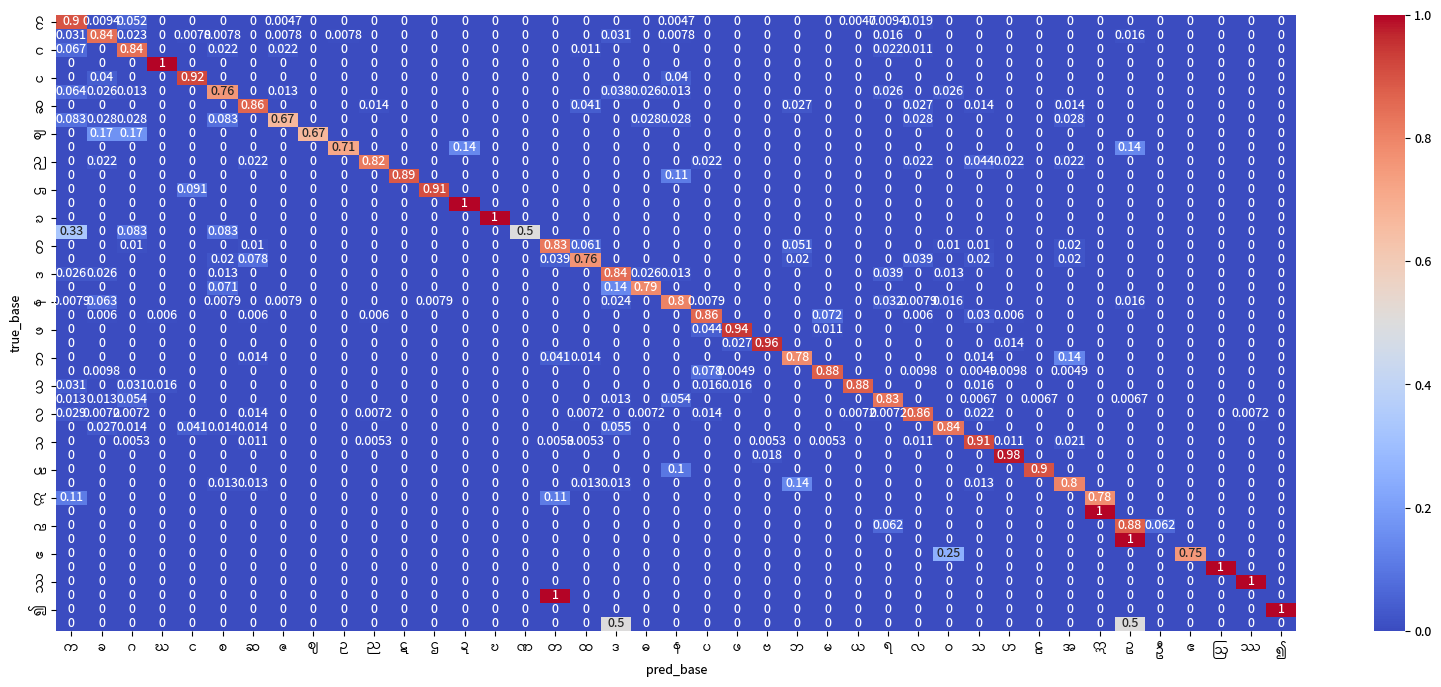

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 8)) 
sns.heatmap(base_cm_norm, annot=True, cmap='coolwarm')
plt.show()

#### Units Prototype

The segmental HMM is trained using Viterbi re-estimation rather than full Baum-Welch.

In [16]:
from segmental_hmm import (
    SegmentalHMMConfig,
    train_segmental_hmm,
)

hmm_cfg = SegmentalHMMConfig(
    num_pseudo_tokens=64,
    top_k_token_candidates=3,
    max_segment_len=3,
    allow_zero_len_chars=True,
    num_viterbi_iters=10,
)

seg_model_units = train_segmental_hmm(
    train_emb_df,
    config=hmm_cfg,
    emb_col="embedding",
    syllable_col="syllable",
    char_array_col="align_unit_array",
    sample_index_col="sample_index",
    stroke_index_col="stroke_index",
)


/media/kyalkalay/Data/AI-Class/modified-assignment-3/modified-assignment-3/MM_HW_Recognition/segmental_hmm.py:639: UserWarning: Viterbi iteration 1: 22 training samples could not be aligned.
  warnings.warn(f"Viterbi iteration {it+1}: {num_failed} training samples could not be aligned.")
/media/kyalkalay/Data/AI-Class/modified-assignment-3/modified-assignment-3/MM_HW_Recognition/segmental_hmm.py:639: UserWarning: Viterbi iteration 2: 22 training samples could not be aligned.
  warnings.warn(f"Viterbi iteration {it+1}: {num_failed} training samples could not be aligned.")
/media/kyalkalay/Data/AI-Class/modified-assignment-3/modified-assignment-3/MM_HW_Recognition/segmental_hmm.py:639: UserWarning: Viterbi iteration 3: 22 training samples could not be aligned.
  warnings.warn(f"Viterbi iteration {it+1}: {num_failed} training samples could not be aligned.")
/media/kyalkalay/Data/AI-Class/modified-assignment-3/modified-assignment-3/MM_HW_Recognition/segmental_hmm.py:639: UserWarning: Viter

In [17]:
from aligned_component_dataset import (
    AlignedComponentDatasetConfig,
    build_aligned_component_dataset,
    evaluate_alignment_coverage,
)

align_dbg_cfg = AlignedComponentDatasetConfig(
    segment_embedding_mode="mean",
    keep_zero_length_segments=True,
)

dbg_component_df, dbg_align_summary_df = build_aligned_component_dataset(
    train_emb_df,
    seg_model_units,
    config=align_dbg_cfg,
    emb_col="embedding",
    sample_index_col="sample_index",
    stroke_index_col="stroke_index",
    char_array_col="align_unit_array",
)

display(evaluate_alignment_coverage(dbg_align_summary_df))
display(dbg_component_df.head())

,metric,value
0,num_samples,10570.000000
1,alignment_success_rate,0.997919
2,num_failed_alignments,22.000000


,sample_index,target_symbol,target_pos,role,position_tag,segment_len_strokes,segment_start_stroke,segment_end_stroke,segment_embedding
0,2522,အ,0,BASE,START,2,0,2,"[-0.027865265, 0.005716797, 0.015171766, 0.021..."
1,2522,ု,1,VOWEL,MID,1,2,3,"[-0.012895074, 0.03424957, 0.00400764, 0.01625..."
2,2522,တ်,2,ASAT,END,3,3,6,"[0.020867132, 0.0003590534, 0.017361732, 0.020..."
3,8013,လ,0,BASE,START,2,0,2,"[-0.028181635, 0.012494979, 0.010631008, 0.013..."
4,8013,တ်,1,ASAT,MID,3,2,5,"[-0.001491452, 0.009019588, 0.012821068, 0.011..."


In [18]:
from unit_prototype import (
    BaselineUnitRuleConfig,
    build_baseline_unit_dataset,
    UnitPrototypeConfig,
    train_unit_prototype_bank,
)

rule_cfg = BaselineUnitRuleConfig(
    merge_medial_triplets=False,
    min_auto_pair_count=20,
    min_auto_zero_rate=0.25,
    embedding_agg_mode="mean",
)

baseline_unit_df = build_baseline_unit_dataset(
    dbg_component_df,
    config=rule_cfg,
)

unit_proto_cfg = UnitPrototypeConfig(
    prototype_mode="medoid",
    normalize=True,
    max_prototypes_per_unit=2,
)

unit_proto_bank = train_unit_prototype_bank(
    baseline_unit_df,
    unit_col="baseline_unit",
    emb_col="segment_embedding",
    config=unit_proto_cfg,
)

print("Baseline units:", len(unit_proto_bank["units"]))
print(list(unit_proto_bank["units"].keys())[:30])

Baseline units: 156
['အ', 'မ', 'က', 'ိ', 'ု', 'ပ', 'ါ', 'တ', 'ယ်', 'သ', 'ည်', 'ှ', 'ာ', 'ရ', 'ေန', 'ူ', 'ေတ', 'ာ်', 'ျွ', 'န်', 'ွ', 'ေ', 'လ', 'း', '့', 'စ်', 'ဖ', 'ြ', 'ဲ', 'ဘ']


/tmp/ipykernel_7259/2755879111.py:893: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(seg_df))


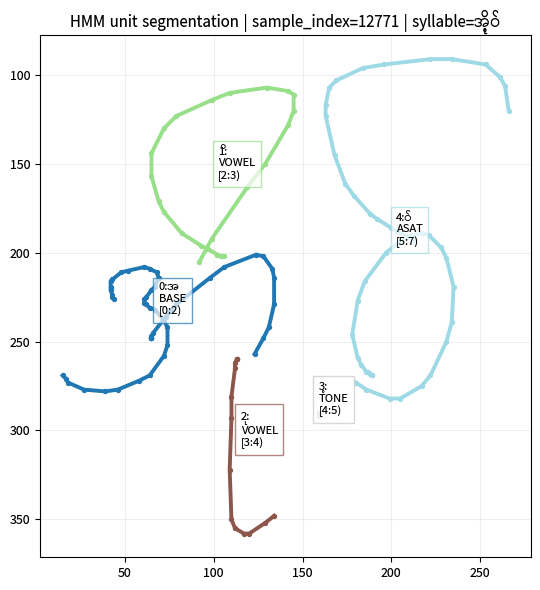

/tmp/ipykernel_7259/2755879111.py:834: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", max(n, 1))


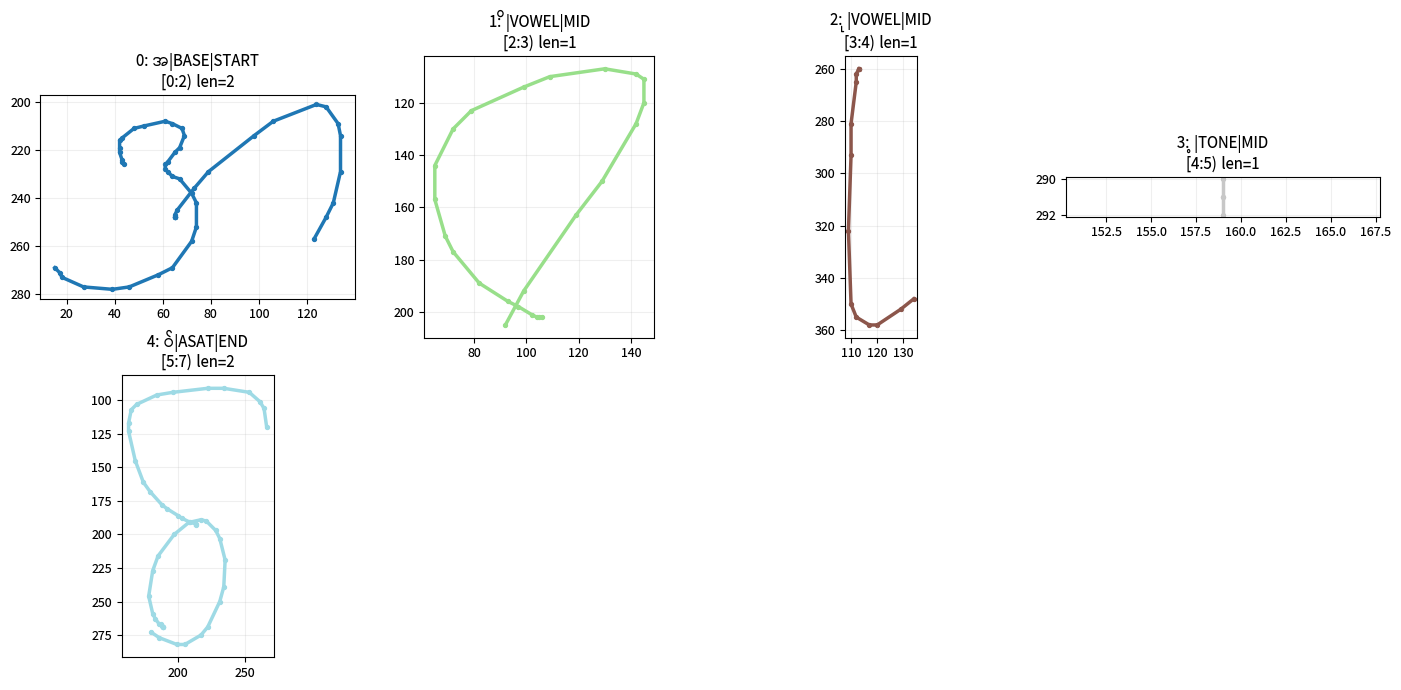

In [67]:
import random
sample_id = int(train_df.iloc[random.randrange(1,len(train_df),1)]["sample_index"])
plot_hmm_unit_segmentation(full_emb_df, dbg_component_df, sample_id)
plot_hmm_unit_panels(full_emb_df, dbg_component_df, sample_id)

/tmp/ipykernel_7259/2755879111.py:893: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(seg_df))


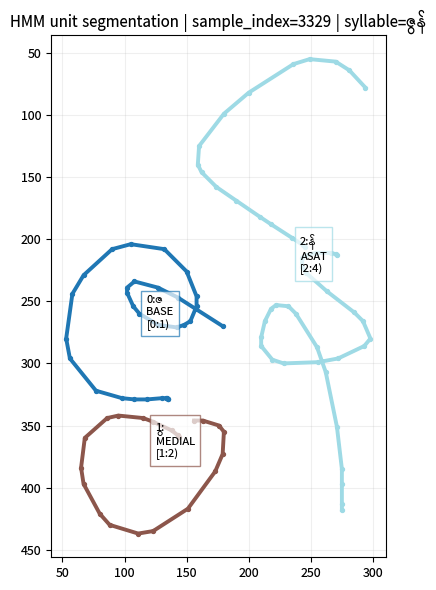

/tmp/ipykernel_7259/2755879111.py:834: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", max(n, 1))


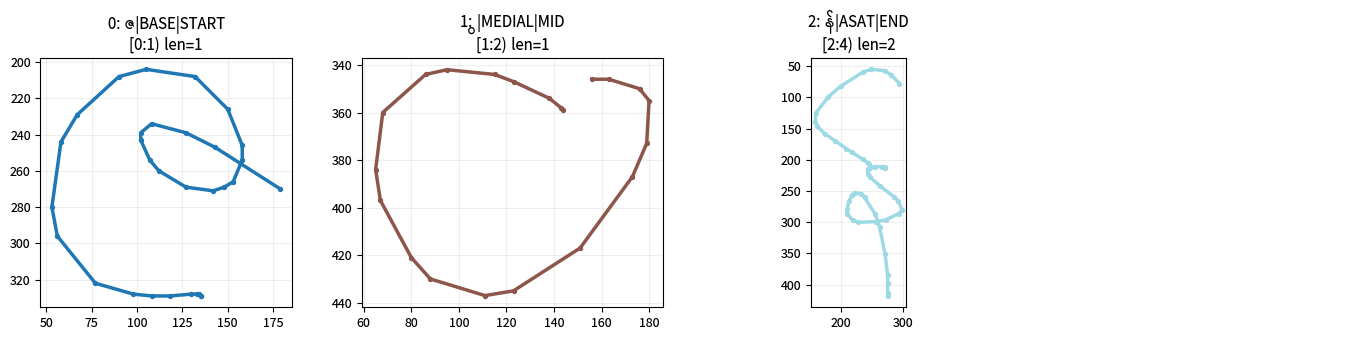

In [68]:
import random
sample_id = int(train_df.iloc[random.randrange(1,len(train_df),1)]["sample_index"])
plot_hmm_unit_segmentation(full_emb_df, dbg_component_df, sample_id)
plot_hmm_unit_panels(full_emb_df, dbg_component_df, sample_id)

/tmp/ipykernel_7259/2755879111.py:893: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(seg_df))


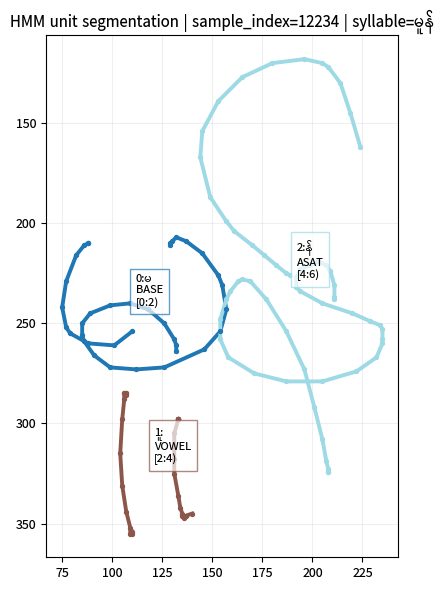

/tmp/ipykernel_7259/2755879111.py:834: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", max(n, 1))


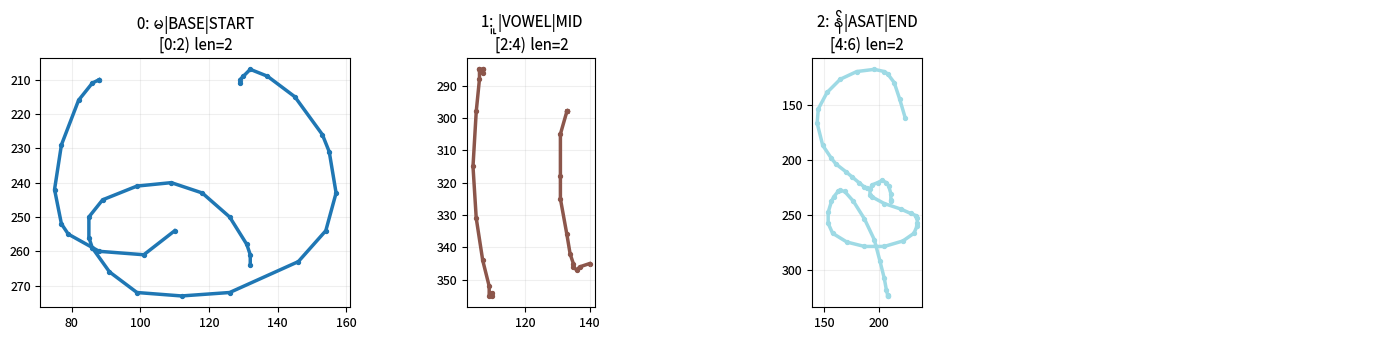

In [74]:
import random
sample_id = int(train_df.iloc[random.randrange(1,len(train_df),1)]["sample_index"])
plot_hmm_unit_segmentation(full_emb_df, dbg_component_df, sample_id)
plot_hmm_unit_panels(full_emb_df, dbg_component_df, sample_id)

/tmp/ipykernel_7259/2755879111.py:893: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(seg_df))


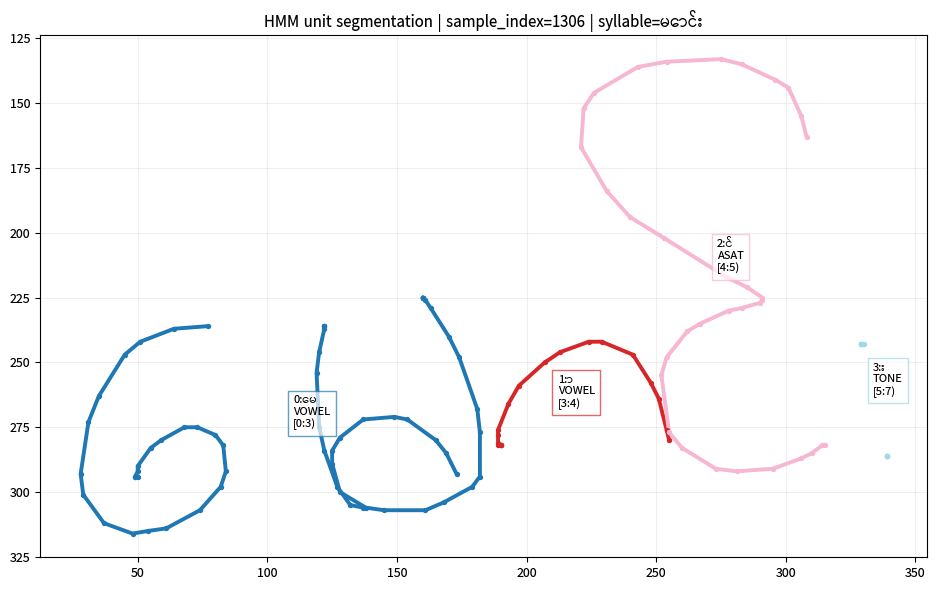

/tmp/ipykernel_7259/2755879111.py:834: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", max(n, 1))


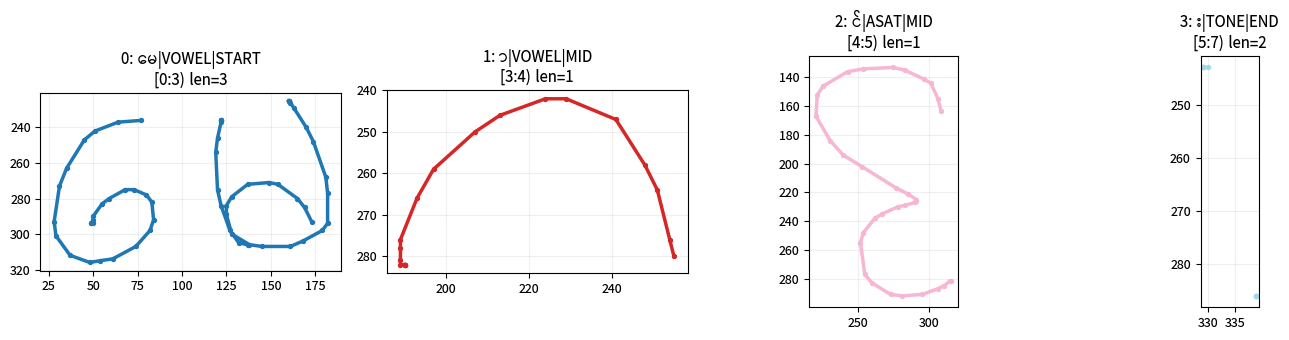

In [22]:
import random
sample_id = (437*3)-5
plot_hmm_unit_segmentation(full_emb_df, dbg_component_df, sample_id)
plot_hmm_unit_panels(full_emb_df, dbg_component_df, sample_id)

In [23]:
from segmental_hmm import (
    build_token_lattice_from_emb_df,
)



from prototype import (
    batch_recall_syllable_candidates
)


from unit_prototype import build_syllable_to_units

test_items_units = build_token_lattice_from_emb_df(
    test_emb_df,
    seg_model_units["tokenizer"],
    emb_col="embedding",
    sample_index_col="sample_index",
    stroke_index_col="stroke_index",
    syllable_col="syllable",
    char_array_col="align_unit_array",
)



syllable_to_units = build_syllable_to_units(syllable_df)

shortlist_by_sample = batch_recall_syllable_candidates(
    test_emb_df,
    prototype_bank,
    max_segment_len=3,
    shape_top_k=25,
    stroke_margin=1,
    char_margin=0,
    prototype_config=proto_cfg,
)

first_sid = next(iter(shortlist_by_sample.keys()))

In [24]:
from unit_prototype import (
    UnitGrammarConfig,
    build_unit_to_role_map,
    build_role_bigram_logprob,
    score_unit_sequence_with_grammar,
)

syllable_to_char_array = {
    row["syllable"]: tuple(row["char_array"])
    for _, row in syllable_df.iterrows()
}


unit_to_role = build_unit_to_role_map(baseline_unit_df)

role_bigram_logprob = build_role_bigram_logprob(
    train_df,
    syllable_to_units=syllable_to_units,
    unit_to_role=unit_to_role,
    smoothing=1.0,
)

grammar_cfg = UnitGrammarConfig(
    enable_grammar=True,
    lambda_grammar=0.20,
    smoothing=1.0,
)

In [25]:
from segmental_hmm import decode_one_sample_segmental_hmm
rows = []

test_sample_ids = (
    test_emb_df["sample_index"]
    .drop_duplicates()
    .astype(int)
    .tolist()
)

for sid in test_sample_ids:
    gt = (
        test_emb_df.loc[test_emb_df["sample_index"] == sid, "syllable"]
        .iloc[0]
    )

    topk, cand_df, branch_info = hybrid_decode_sample_dynamic(
        sample_index=sid,
        emb_df=test_emb_df,
        test_items_units=test_items_units,
        seg_model_units=seg_model_units,
        prototype_bank=prototype_bank,
        unit_proto_bank=unit_proto_bank,
        syllable_to_units=syllable_to_units,
        shortlist_by_sample=shortlist_by_sample,
        unit_to_role=unit_to_role,
        role_bigram_logprob=role_bigram_logprob,
        grammar_cfg=grammar_cfg,
        unit_proto_cfg=unit_proto_cfg,
        syllable_to_first_base=syllable_to_first_base,
        final_top_k=10,
    )

    rows.append({
        "sample_index": sid,
        "true_syllable": gt,
        "pred_top1": topk[0] if len(topk) > 0 else None,
        "pred_topk": topk,
        "w_syll": branch_info["w_syll"],
        "w_unit": branch_info["w_unit"],
        "conf_syll": branch_info["conf_syll"],
        "conf_unit": branch_info["conf_unit"],
        "hmm_gap": branch_info["hmm_gap"],
        "proto_gap": branch_info["proto_gap"],
        "same_base_gap": branch_info["same_base_gap"],
        "unit_agree": branch_info["unit_agree"],
        "zero_rate": branch_info["zero_rate"],
        "bad_zero_role_count": branch_info["bad_zero_role_count"],
        "top1_source": branch_info["top1_source"],
    })


final_pred_df_dynamic = pd.DataFrame(rows)
# final_pred_df_dynamic.head()

In [26]:
train_count_by_syll = (
    train_df["syllable"]
    .astype(str)
    .value_counts()
    .to_dict()
)

eval_df = final_pred_df_dynamic.copy()
eval_df["train_count"] = eval_df["true_syllable"].astype(str).map(train_count_by_syll).fillna(0).astype(int)

seen_df = eval_df[eval_df["train_count"] > 0].copy()
unseen_df = eval_df[eval_df["train_count"] == 0].copy()

print("=== Overall ===")
print("Top‑1 :", topk_accuracy_from_pred_df(eval_df, 1))
print("Top‑5 :", topk_accuracy_from_pred_df(eval_df,5))
print("Top‑10:", topk_accuracy_from_pred_df(eval_df, 10))

print("\n=== Seen only ===")
print("Top‑1 :", topk_accuracy_from_pred_df(seen_df, 1))
print("Top‑5 :", topk_accuracy_from_pred_df(seen_df, 5))
print("Top‑10:", topk_accuracy_from_pred_df(seen_df, 10))


=== Overall ===
Top‑1 : 0.7703367385546728
Top‑5 : 0.9035187287173666
Top‑10: 0.9216799091940976

=== Seen only ===
Top‑1 : 0.7984313725490196
Top‑5 : 0.9364705882352942
Top‑10: 0.9552941176470588


In [27]:
unit_base_cm = base_confusion_matrix(seen_df, syllable_to_first_base)
unit_base_cm_norm = base_confusion_matrix_normalized(seen_df, syllable_to_first_base)

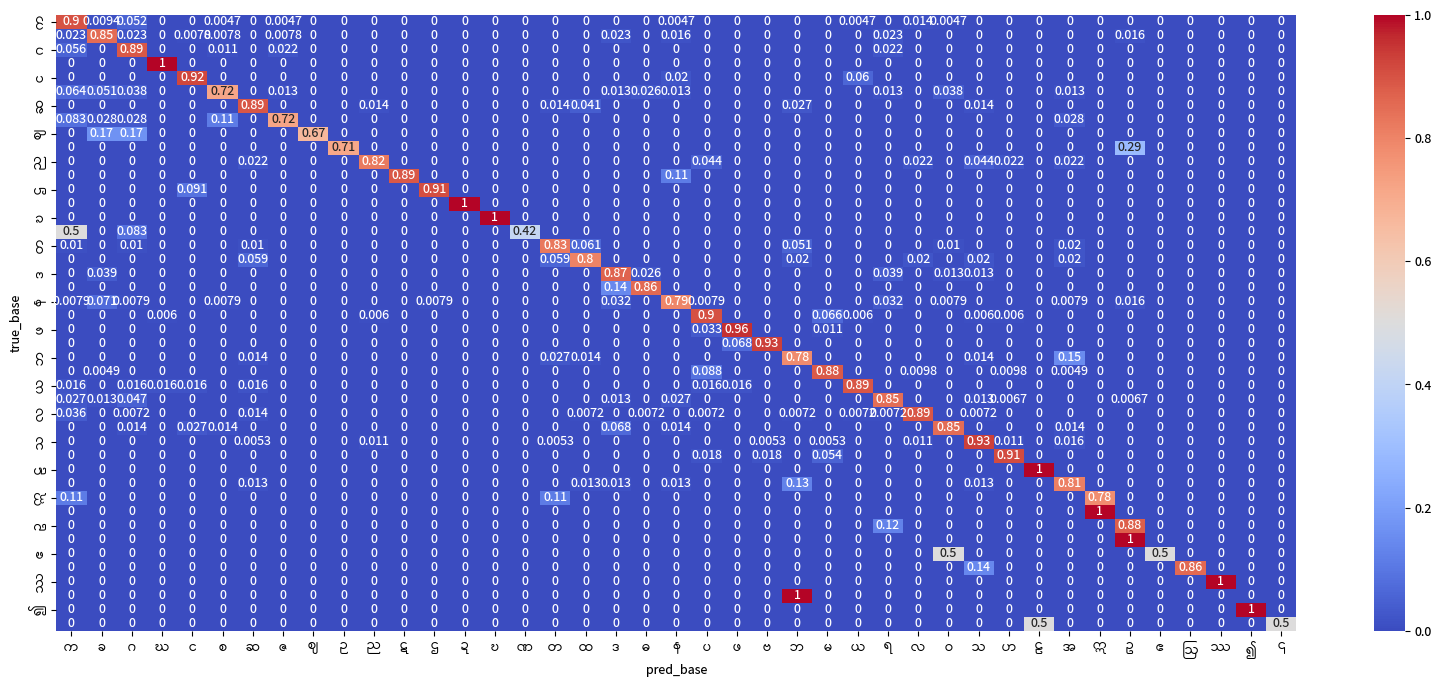

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 8)) 
sns.heatmap(unit_base_cm_norm, annot=True, cmap='coolwarm')
plt.show()

In [29]:
err_df = final_pred_df_dynamic[final_pred_df_dynamic["pred_top1"] != final_pred_df_dynamic["true_syllable"]].copy()

conf_pairs = (
    err_df
    .groupby(["true_syllable", "pred_top1"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print("Num errors:", len(err_df))
# conf_pairs.head(30)

Num errors: 607


In [30]:
import random
sample_id = err_df['sample_index'].tolist()[random.randrange(1,len(err_df),1)]

gt = test_emb_df.loc[
    test_emb_df["sample_index"] == sample_id,
    "syllable"
].iloc[0]

print(gt)

topk, cand_df, branch_info = hybrid_decode_sample_dynamic(
    sample_index=sample_id,
    emb_df=test_emb_df,
    test_items_units=test_items_units,
    seg_model_units=seg_model_units,
    prototype_bank=prototype_bank,
    unit_proto_bank=unit_proto_bank,
    syllable_to_units=syllable_to_units,
    shortlist_by_sample=shortlist_by_sample,
    unit_to_role=unit_to_role,
    role_bigram_logprob=role_bigram_logprob,
    grammar_cfg=grammar_cfg,
    unit_proto_cfg=unit_proto_cfg,
    syllable_to_first_base=syllable_to_first_base, 
    final_top_k=10,
)

print("Top‑10:", topk)
print(branch_info)
display(cand_df.head(10))

ညုန်း
Top‑10: ['အုန်း', 'ပွန်း', 'လွန်း', 'ညှဉ်း', 'ထည်း', 'ရှမ်း', 'ချည်း', 'သုန်း', 'ရှုန်း', 'ဘုန်း']
{'conf_syll': 0.35222087387314693, 'conf_unit': 0.4035152555627952, 'top1_syll_prob': 0.47029841770486136, 'top2_syll_prob': 0.11807754383171445, 'w_syll': 0.6, 'w_unit': 0.4, 'same_base_ok': False, 'unit_support': 0.2014061022251181, 'top1_source': 'blend', 'top1_syll_label': 'အုန်း', 'top1_unit_label': 'သုန်း', 'unit_trust': np.float64(0.4035152555627952), 'hmm_gap': np.float64(0.23863348228833847), 'proto_gap': np.float64(0.01860221659307093), 'same_base_gap': np.float64(1.0828072312216868), 'unit_agree': False, 'zero_rate': np.float64(0.0), 'bad_zero_role_count': np.int64(0)}


,syllable,syll_score,unit_hmm_score,unit_proto_score,first_base,zero_rate,bad_zero_role_count,syll_norm,unit_hmm_norm,unit_proto_norm,unit_model_score,final_score
0,အုန်း,0.920044,-16.034346,0.397935,အ,0.0,0,2.216746,0.932869,0.417324,0.829760,1.661952
1,ပွန်း,0.908718,-19.919077,0.354998,ပ,0.0,0,1.525733,-0.094533,0.164958,-0.042635,0.898386
2,လွန်း,0.908147,-20.490635,0.360334,လ,0.0,0,1.490949,-0.245694,0.196316,-0.157292,0.831653
3,ညှဉ်း,0.904109,-18.634371,0.328409,ည,0.0,0,1.244534,0.245236,0.008675,0.197924,0.825890
4,ထည်း,0.907373,-22.686878,0.412377,ထ,0.0,0,1.443703,-0.826539,0.502210,-0.560789,0.641906
5,ရှမ်း,0.896026,-17.378248,0.331365,ရ,0.0,0,0.751392,0.577445,0.026046,0.467165,0.637701
6,ချည်း,0.898565,-19.818323,0.329637,ခ,0.0,0,0.906293,-0.067886,0.015891,-0.051131,0.523324
7,သုန်း,0.885644,-14.963232,0.408805,သ,0.0,0,0.117962,1.216149,0.481213,1.069162,0.498442
8,ရှုန်း,0.890148,-16.015579,0.211802,ရ,0.0,0,0.392792,0.937833,-0.676709,0.614924,0.481645
9,ဘုန်း,0.879372,-15.938988,0.402816,ဘ,0.0,0,-0.264698,0.958089,0.446012,0.855674,0.183450


In [31]:
import random
sample_id = err_df['sample_index'].tolist()[random.randrange(1,len(err_df),1)]

gt = test_emb_df.loc[
    test_emb_df["sample_index"] == sample_id,
    "syllable"
].iloc[0]

print(gt)

topk, cand_df, branch_info = hybrid_decode_sample_dynamic(
    sample_index=sample_id,
    emb_df=test_emb_df,
    test_items_units=test_items_units,
    seg_model_units=seg_model_units,
    prototype_bank=prototype_bank,
    unit_proto_bank=unit_proto_bank,
    syllable_to_units=syllable_to_units,
    shortlist_by_sample=shortlist_by_sample,
    unit_to_role=unit_to_role,
    role_bigram_logprob=role_bigram_logprob,
    grammar_cfg=grammar_cfg,
    unit_proto_cfg=unit_proto_cfg,
    syllable_to_first_base=syllable_to_first_base,   # ✅ NEW
    final_top_k=10,
)

print("Top‑10:", topk)
print(branch_info)
display(cand_df.head(10))

ဘို့
Top‑10: ['အို့', 'ထို့', 'တို့', 'ညို့', 'ဘို့', 'ဆို့', 'ချို့', 'မို့', 'အုံ့', 'နှို့']
{'conf_syll': 0.15113154166555567, 'conf_unit': 0.4140500317088709, 'top1_syll_prob': 0.36150306858926096, 'top2_syll_prob': 0.21037152692370528, 'w_syll': 0.6, 'w_unit': 0.4, 'same_base_ok': False, 'unit_support': 0.20562001268354835, 'top1_source': 'blend', 'top1_syll_label': 'အို့', 'top1_unit_label': 'ဆို့', 'unit_trust': np.float64(0.4140500317088709), 'hmm_gap': np.float64(0.23331122746207567), 'proto_gap': np.float64(0.03842350530849403), 'same_base_gap': np.float64(1.8134985735316245), 'unit_agree': False, 'zero_rate': np.float64(0.0), 'bad_zero_role_count': np.int64(0)}


,syllable,syll_score,unit_hmm_score,unit_proto_score,first_base,zero_rate,bad_zero_role_count,syll_norm,unit_hmm_norm,unit_proto_norm,unit_model_score,final_score
0,အို့,0.943417,-12.736305,0.004465,အ,0.0,0,1.918247,1.388525,0.804193,1.271658,1.659612
1,ထို့,0.929500,-12.298321,0.012195,ထ,0.0,0,1.647550,1.536143,0.894614,1.407837,1.551665
2,တို့,0.913451,-12.677359,0.015193,တ,0.0,0,1.335378,1.408392,0.929690,1.312652,1.326287
3,ညို့,0.902610,-14.968718,0.019955,ည,0.0,0,1.124523,0.636115,0.985385,0.705969,0.957101
4,ဘို့,0.879018,-12.465490,0.016268,ဘ,0.0,0,0.665637,1.479800,0.942258,1.372292,0.948299
5,ဆို့,0.863952,-11.606083,0.016670,ဆ,0.0,0,0.372612,1.769454,0.946961,1.604955,0.865549
6,ချို့,0.890858,-13.982622,-0.170701,ခ,0.0,0,0.895945,0.968467,-1.244740,0.525826,0.747897
7,မို့,0.871438,-16.169477,-0.002450,မ,0.0,0,0.518204,0.231412,0.723307,0.329791,0.442839
8,အုံ့,0.883854,-17.897293,-0.041850,အ,0.0,0,0.759708,-0.350930,0.262441,-0.228256,0.364522
9,နှို့,0.857758,-14.088732,-0.195633,န,0.0,0,0.252122,0.932704,-1.536374,0.438889,0.326829


In [32]:
import numpy as np
import pandas as pd

analysis_df = final_pred_df_dynamic.copy()

analysis_df["correct_top1"] = (
    analysis_df["pred_top1"].astype(str) == analysis_df["true_syllable"].astype(str)
)

analysis_df["correct_top5"] = analysis_df.apply(
    lambda r: str(r["true_syllable"]) in [str(x) for x in r["pred_topk"][:5]],
    axis=1,
)

analysis_df["correct_top10"] = analysis_df.apply(
    lambda r: str(r["true_syllable"]) in [str(x) for x in r["pred_topk"][:10]],
    axis=1,
)

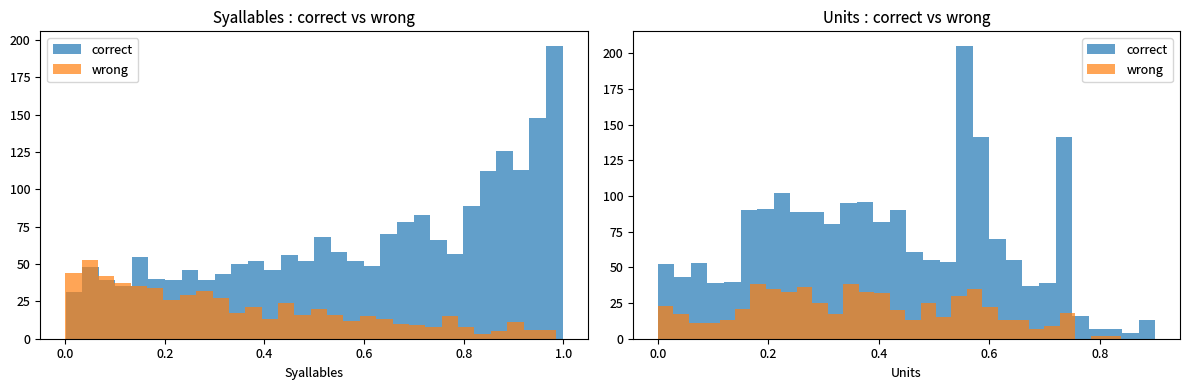

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    analysis_df.loc[analysis_df["correct_top1"], "conf_syll"],
    bins=30, alpha=0.7, label="correct"
)
axes[0].hist(
    analysis_df.loc[~analysis_df["correct_top1"], "conf_syll"],
    bins=30, alpha=0.7, label="wrong"
)
axes[0].set_title("Syallables : correct vs wrong")
axes[0].set_xlabel("Syallables")
axes[0].legend()

axes[1].hist(
    analysis_df.loc[analysis_df["correct_top1"], "conf_unit"],
    bins=30, alpha=0.7, label="correct"
)
axes[1].hist(
    analysis_df.loc[~analysis_df["correct_top1"], "conf_unit"],
    bins=30, alpha=0.7, label="wrong"
)
axes[1].set_title("Units : correct vs wrong")
axes[1].set_xlabel("Units")
axes[1].legend()

plt.tight_layout()
plt.show()

## Save & Load Model

#### Save Model to pkl

In [34]:
# Save Model

from offline_export import save_frozen_decoder_artifacts

save_frozen_decoder_artifacts(
    export_dir="model_1",
    prototype_bank=prototype_bank,
    unit_proto_bank=unit_proto_bank,
    seg_model_units=seg_model_units,
    syllable_df=syllable_df,
    syllable_to_units=syllable_to_units,
    unit_to_role=unit_to_role,
    role_bigram_logprob=role_bigram_logprob,
    grammar_cfg=grammar_cfg,
    unit_proto_cfg=unit_proto_cfg,
)

[OK] Saved frozen decoder artifacts to: model_1


#### Load Model from pkl

In [35]:
#Load Model


# import importlib
# import production_decoder

# importlib.reload(production_decoder)

from production_decoder import PiProductionDecoder

decoder = PiProductionDecoder.load("model_1")

#### Predict

In [36]:
sample_id = test_emb_df['sample_index'].tolist()[random.randrange(1,len(test_df),1)]

gt = test_emb_df.loc[
    test_emb_df["sample_index"] == sample_id,
    "syllable"
].iloc[0]

print(gt)

topk, cand_df, branch_info = decoder.predict_from_emb_df(
    sample_index=sample_id,
    emb_df=test_emb_df,
    item_units=None,  
    return_debug=True,
)

print("Top‑10:", topk)
print(branch_info)

သေဋ္ဌေး
Top‑10: ['သေဋ္ဌေး', 'သန္တေး', 'ညိမ်း', 'ဗျူး', 'သောပ္ပ', 'ဩောင်း', 'လတ္တံ့', 'သေတ္တာ', 'မျိူး', 'သေတ္တု']
{'conf_syll': 4.1604829058631, 'conf_unit': 0.55, 'w_syll': 0.6, 'w_unit': 0.4, 'unit_support': 0.26, 'same_base_ok': False, 'top1_source': 'blend', 'top1_syll_label': 'သေဋ္ဌေး', 'top1_unit_label': 'ညိမ်း', 'unit_trust': 0.55, 'hmm_gap': np.float64(0.6902167567489095), 'proto_gap': np.float64(0.8164737724928763), 'same_base_gap': 0.0, 'unit_agree': False, 'zero_rate': np.float64(0.0), 'bad_zero_role_count': np.int64(0)}


In [39]:
sample_id = test_emb_df['sample_index'].tolist()[random.randrange(1,len(test_df),1)]

gt = test_emb_df.loc[
    test_emb_df["sample_index"] == sample_id,
    "syllable"
].iloc[0]

print(gt)

topk, cand_df, branch_info = decoder.predict_from_emb_df(
    sample_index=sample_id,
    emb_df=test_emb_df,
    item_units=None,  
    return_debug=True,
)

print("Top‑10:", topk)
print(branch_info)

သိပ္ပိ
Top‑10: ['သိပ္ပိ', 'လိမ္မာ', 'သမ္ဗိ', 'ဘုမ္မိ', 'မိတ္ထီ', 'သဗ္ဗ', 'သမ္မန်', 'သမ္မော', 'မိလ္လာ', 'ဟတ္ထိ']
{'conf_syll': 3.461134070130233, 'conf_unit': 0.41307519132062426, 'w_syll': 0.6, 'w_unit': 0.4, 'unit_support': 0.2052300765282497, 'same_base_ok': True, 'top1_source': 'unit_same_base_support', 'top1_syll_label': 'သိပ္ပိ', 'top1_unit_label': 'သိပ္ပိ', 'unit_trust': 0.41307519132062426, 'hmm_gap': np.float64(0.24352997879887228), 'proto_gap': np.float64(0.3682608866989361), 'same_base_gap': np.float64(0.029317818782627958), 'unit_agree': False, 'zero_rate': np.float64(0.0), 'bad_zero_role_count': np.int64(0)}


In [64]:
sample_id = test_emb_df['sample_index'].tolist()[random.randrange(1,len(test_df),1)]

gt = test_emb_df.loc[
    test_emb_df["sample_index"] == sample_id,
    "syllable"
].iloc[0]

print(gt)

topk, cand_df, branch_info = decoder.predict_from_emb_df(
    sample_index=sample_id,
    emb_df=test_emb_df,
    item_units=None,  
    return_debug=True,
)

print("Top‑10:", topk)
print(branch_info)

ဟေလ်
Top‑10: ['မောလ်', 'ဘောလ်', 'ပေါလ်', 'ဟေလ်', 'ဂုန္တန်', 'အောလ်', 'ဗောက်', 'ဃာတ်', 'ဘောမ်', 'ဟောက်']
{'conf_syll': 2.0406349663884744, 'conf_unit': 0.55, 'w_syll': 0.6, 'w_unit': 0.4, 'unit_support': 0.26, 'same_base_ok': False, 'top1_source': 'blend', 'top1_syll_label': 'ဟေလ်', 'top1_unit_label': 'ဂုန္တန်', 'unit_trust': 0.55, 'hmm_gap': np.float64(0.7991657632814246), 'proto_gap': np.float64(0.3087121313592345), 'same_base_gap': 0.0, 'unit_agree': False, 'zero_rate': np.float64(0.0), 'bad_zero_role_count': np.int64(0)}


In [83]:
err_df[['true_syllable','pred_top1','pred_topk','conf_syll','conf_unit','hmm_gap','proto_gap','same_base_gap','top1_source']].head()

,true_syllable,pred_top1,pred_topk,conf_syll,conf_unit,hmm_gap,proto_gap,same_base_gap,top1_source
1,အိန္ဒြာ,အိန္တာ,"[အိန္တာ, အိန္မာ, အိန္ဒြာ, အတ္ထာ, ဘိန္ဒော, ဘိဇ္...",0.093409,0.750000,1.300510,0.462479,0.764593,unit_same_base_support
5,မုက်,ပုဏ်,"[ပုဏ်, ပုဂ်, မုခ်, မှက်, ပုစ်, ပွက်, မုစ်, မုဉ...",0.303038,0.214370,0.050115,0.226971,0.049018,unit_same_base_support
6,စန္န,စန္ဒ,"[စန္ဒ, စန္န, ခန္ဓ, ဇန္န, ဂန္ဓ, ရန္န, ကန္ဒ, ဝန္...",0.065439,0.514808,0.164808,3.413439,0.503670,blend
9,လန်း,လျင်း,"[လျင်း, ကျန်း, ဂျန်း, လန်း, ကည်း, ဆန်း, ချဉ်း,...",0.506879,0.000000,0.004899,0.024014,0.000000,blend
10,ဖြစ်,မြစ်,"[မြစ်, ပြစ်, ပြက်, မျက်, ပျစ်, မြက်, ပြန်, ပျက...",0.071075,0.114262,0.081154,0.053628,0.060308,blend


In [78]:
err_df[['true_syllable','pred_topk']].head(20)

,true_syllable,pred_topk
1,အိန္ဒြာ,"[အိန္တာ, အိန္မာ, အိန္ဒြာ, အတ္ထာ, ဘိန္ဒော, ဘိဇ္..."
5,မုက်,"[ပုဏ်, ပုဂ်, မုခ်, မှက်, ပုစ်, ပွက်, မုစ်, မုဉ..."
6,စန္န,"[စန္ဒ, စန္န, ခန္ဓ, ဇန္န, ဂန္ဓ, ရန္န, ကန္ဒ, ဝန္..."
9,လန်း,"[လျင်း, ကျန်း, ဂျန်း, လန်း, ကည်း, ဆန်း, ချဉ်း,..."
10,ဖြစ်,"[မြစ်, ပြစ်, ပြက်, မျက်, ပျစ်, မြက်, ပြန်, ပျက..."
21,ရိုက်,"[ရိုဏ်, ခိုက်, စိုက်, ဒိုက်, ဝိုက်, ဂိုက်, နို..."
22,ဟီး,"[ပြီး, ကျဉ်း, ပန်း, မြီး, ဗီး, ညဉ်း, ဖင်း, မွင..."
28,ဂူး,"[ရူး, နူး, ငူး, ဂူး, ဝူး, ကူး, စူး, ခူး, ဒူး, ..."
37,လိမ်း,"[ကျိမ်း, သိမ်း, လွမ်း, ထိမ်း, လျှမ်း, လှည်း, ခ..."
41,သင်္ချာ,"[ဗင်္ဂါ, သည့်, ထည့်, သျှောင်, ဗျို, မည့်, ပန္န..."
